In [1]:
# =============================================================================
# Setup and Data Extraction
# =============================================================================
import os
import sys
import pandas as pd
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 20)

# Initialize Spark session
try:
    spark = SparkSession.builder.getOrCreate()
except Exception as e:
    print(f"Standard session creation failed, falling back to managed utils. Error: {e}")
    sys.path.append('/opt/conda/lib/python3.13/site-packages')
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

/home/hmacgregor/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Standard session creation failed, falling back to managed utils. Error: [PACKAGE_NOT_INSTALLED] grpcio-status >= 1.48.1 must be installed; however, it was not found.


In [2]:
# =============================================================================
# Extract High‑Quality Environmental MAGs
# =============================================================================
genomes = spark.table("kescience_mgnify.genome").filter(
    (F.col("completeness") >= 90.0) & 
    (F.col("contamination") <= 5.0)
)

metal_amr = spark.table("kescience_mgnify.gene_amr").filter(
    F.col("element_subtype") == "METAL"
).cache()

mag_metal_diversity = metal_amr.groupBy("genome_id").agg(
    F.countDistinct("amr_class").alias("n_metal_types")
)

biomes = spark.table("kescience_mgnify.biome").select("biome_id", "biome_name", "biome_lineage")

mag_master_spark = genomes.join(
    mag_metal_diversity, on="genome_id", how="left"
).fillna({"n_metal_types": 0}).join(
    biomes, on="biome_id", how="inner"
).filter(
    ~F.lower(F.col("biome_lineage")).like("%host-associated%")
).cache()

env_mags_spark = mag_master_spark  # already filtered
print(f"Extracted {env_mags_spark.count()} high-quality environmental MAGs.")

Extracted 30497 high-quality environmental MAGs.


In [3]:
# =============================================================================
# Feature Integration & Cross‑Validation Split
# =============================================================================
quality = spark.table("kescience_mgnify.genome").select(
    "genome_id", 
    F.col("completeness").alias("qc_completeness"),
    F.col("contamination").alias("qc_contamination")
)

cazy = spark.table("kescience_mgnify.genome_cazy").groupBy("genome_id").agg(
    F.countDistinct("cazy_family").alias("feat_carbon_versatility")
)

mags_complete_spark = env_mags_spark \
    .join(quality, "genome_id", "left") \
    .join(cazy, "genome_id", "left") \
    .fillna(0)

# Split into discovery (70%) and validation (30%) sets
discovery_mags, validation_mags = mags_complete_spark.randomSplit([0.7, 0.3], seed=42)
discovery_mags.cache()
validation_mags.cache()

print(f"Discovery Set: {discovery_mags.count()} MAGs")
print(f"Validation Set: {validation_mags.count()} MAGs")

Discovery Set: 21474 MAGs
Validation Set: 9023 MAGs


In [4]:
# =============================================================================
# Comprehensive T4SS Engine Definition (Discovery Set Only)
# =============================================================================
# Use a broad set of markers to capture canonical T4SS and conjugative systems.
t4ss_markers = [
    "COG0741", "COG3504", "COG3505", "COG3846",  # VirB4, VirB6, VirB8, VirB9
    "COG3451", "COG3842",                         # VirB10, VirB11
    "VirB4", "VirD4", "TraI", "TraD", "TrwB", "TraG"
]

t4ss_condition = F.lit(False)
for marker in t4ss_markers:
    t4ss_condition = t4ss_condition | F.col("eggnog_ogs").contains(marker)
t4ss_condition = t4ss_condition | F.lower(F.col("description")).rlike(
    "type iv secretion|conjugal transfer|virb|virb4|virb6|virb8|virb9|virb10|virb11|vird4|trai|trad|trwb|trag"
)

hgt_engine_df = spark.table("kescience_mgnify.gene_eggnog") \
    .join(discovery_mags.select("genome_id"), on="genome_id", how="inner") \
    .filter(t4ss_condition) \
    .select("genome_id").distinct() \
    .withColumn("has_t4ss_engine", F.lit(1)).cache()

total_discovery_mags = discovery_mags.count()
total_t4ss_mags = hgt_engine_df.count()
print(f"Found {total_t4ss_mags} T4SS‑positive genomes out of {total_discovery_mags} in the Discovery set.")

Found 5958 T4SS‑positive genomes out of 21474 in the Discovery set.


In [5]:
# =============================================================================
# Curated Set of HGT‑Associated Accessory Traits (Discovery Set)
# =============================================================================
# Instead of using an FDR‑selected list (which collapses after COG0741 exclusion),
# we define a priori a set of traits known to be associated with horizontal gene transfer.
hgt_keywords = [
    "transposase", "integrase", "recombinase", "conjug",
    "plasmid", "mobil", "toxin", "antitoxin",
    "resistance", "heavy metal", "phage", "capsid", "resolvase"
]

# Build condition
hgt_condition = F.lit(False)
for kw in hgt_keywords:
    hgt_condition = hgt_condition | F.lower(F.col("description")).contains(kw)

hgt_traits = (
    spark.table("kescience_mgnify.gene_eggnog")
    .join(discovery_mags.select("genome_id"), on="genome_id", how="inner")
    .filter(F.col("description") != "-")
    .filter(hgt_condition)
    .filter(~F.lower(F.col("description")).rlike("ribosom|trna|translation"))
    .filter(~F.col("eggnog_ogs").contains("COG0741"))  # exclude intrinsic GH23
    .select("description")
    .distinct()
)

mobile_traits_list = [row.description for row in hgt_traits.collect()]
print(f"Curated set of {len(mobile_traits_list)} HGT‑associated accessory traits.")

Curated set of 2146 HGT‑associated accessory traits.


In [6]:
# =============================================================================
# Count Mobile Traits in Validation Set
# =============================================================================
val_mobile_counts = spark.table("kescience_mgnify.gene_eggnog") \
    .join(validation_mags.select("genome_id"), on="genome_id", how="inner") \
    .filter(F.col("description").isin(mobile_traits_list)) \
    .groupBy("genome_id").agg(F.countDistinct("description").alias("Mobile_Trait_Count"))

validation_pdf = validation_mags.select(
    "genome_id", "feat_carbon_versatility", "length", "qc_completeness", "qc_contamination", "biome_id", "lineage"
).join(val_mobile_counts, on="genome_id", how="left").fillna({"Mobile_Trait_Count": 0}).toPandas()

validation_pdf['length_mb'] = validation_pdf['length'] / 1_000_000.0
validation_pdf['Mobile_Trait_Density'] = validation_pdf['Mobile_Trait_Count'] / validation_pdf['length_mb']
validation_pdf['CAZy_Density'] = validation_pdf['feat_carbon_versatility'] / validation_pdf['length_mb']

print(f"Validation set prepared: {len(validation_pdf)} MAGs with mobile trait counts.")

Validation set prepared: 9023 MAGs with mobile trait counts.


In [7]:
# =============================================================================
# Genome‑Wide Synteny Scan: T4SS vs. CAZy (Excluding Intrinsic GH23)
# =============================================================================
gene_spatial = spark.table("kescience_mgnify.gene").select(
    "gene_id", "genome_id", "contig_id",
    F.col("start").alias("start_pos"), F.col("end").alias("end_pos")
)

# T4SS genes (broad definition, includes COG0741)
t4ss_genes_all = spark.table("kescience_mgnify.gene_eggnog") \
    .join(env_mags_spark.select("genome_id"), on="genome_id", how="inner") \
    .filter(t4ss_condition) \
    .select("genome_id", "gene_id") \
    .join(gene_spatial, on=["genome_id", "gene_id"])

# CAZy genes, excluding those annotated with COG0741
cazy_genes_all = spark.table("kescience_mgnify.gene_eggnog") \
    .join(env_mags_spark.select("genome_id"), on="genome_id", how="inner") \
    .filter(F.col("cazy").isNotNull() & (F.col("cazy") != "-")) \
    .filter(~F.col("eggnog_ogs").contains("COG0741")) \
    .select("genome_id", "gene_id", F.explode(F.split(F.col("cazy"), ",")).alias("cazy_family")) \
    .join(gene_spatial, on=["genome_id", "gene_id"])

# Join on same contig and compute distance
synteny_all = t4ss_genes_all.alias("t4").join(
    cazy_genes_all.alias("cz"),
    (F.col("t4.genome_id") == F.col("cz.genome_id")) & 
    (F.col("t4.contig_id") == F.col("cz.contig_id"))
).withColumn(
    "distance_bp",
    F.greatest(F.lit(0), 
               F.greatest(F.col("t4.start_pos"), F.col("cz.start_pos")) - 
               F.least(F.col("t4.end_pos"), F.col("cz.end_pos")))
).filter(F.col("distance_bp") <= 10000).cache()

synteny_stats = synteny_all.groupBy("cazy_family").agg(
    F.countDistinct("t4.genome_id").alias("n_genomes_syntenic"),
    F.countDistinct("t4.contig_id").alias("n_contigs_syntenic"),
    F.round(F.avg("distance_bp"), 1).alias("avg_distance_bp")
).orderBy(F.desc("n_genomes_syntenic"))

print(f"Genome‑wide synteny scan complete. Found {synteny_stats.count()} CAZy families physically linked to T4SS (≤10 kb).")

Genome‑wide synteny scan complete. Found 92 CAZy families physically linked to T4SS (≤10 kb).


In [8]:
# =============================================================================
# Top CAZy Families Physically Linked to T4SS
# =============================================================================
display(synteny_stats.limit(5).toPandas())

,cazy_family,n_genomes_syntenic,n_contigs_syntenic,avg_distance_bp
0,GT2,767,817,5041.8
1,GH3,653,677,4273.8
2,GH31,611,648,1922.4
3,GT51,611,627,4569.1
4,GH13,610,654,4680.1


In [9]:
# =============================================================================
# Biome Enrichment of Syntenic GT2/T4SS Loci
# =============================================================================
target_family = "GT2"
syntenic_genomes = synteny_all.filter(F.col("cazy_family") == target_family) \
    .select("t4.genome_id").distinct().withColumn("has_syntenic_locus", F.lit(1))

biome_data = env_mags_spark.select("genome_id", "biome_id", "biome_name") \
    .join(syntenic_genomes, on="genome_id", how="left").fillna({"has_syntenic_locus": 0})

biome_stats = biome_data.groupBy("biome_id", "biome_name").agg(
    F.count("genome_id").alias("total_MAGs"),
    F.sum("has_syntenic_locus").alias("syntenic_MAGs")
).withColumn("prevalence", F.col("syntenic_MAGs") / F.col("total_MAGs")).orderBy(F.desc("prevalence"))

biome_stats_pd = biome_stats.toPandas()

# Fisher exact test per biome
total_syntenic = biome_stats_pd["syntenic_MAGs"].sum()
total_mags = biome_stats_pd["total_MAGs"].sum()
results = []
for _, row in biome_stats_pd.iterrows():
    a = row["syntenic_MAGs"]
    b = row["total_MAGs"] - a
    c = total_syntenic - a
    d = total_mags - total_syntenic - b
    odds, p = fisher_exact([[a, b], [c, d]], alternative='greater') if a > 0 else (0.0, 1.0)
    results.append({"biome_name": row["biome_name"], "prevalence": row["prevalence"], "odds_ratio": odds, "p_value": p})

fisher_df = pd.DataFrame(results)
_, qvals, _, _ = multipletests(fisher_df["p_value"], method='fdr_bh')
fisher_df["q_value"] = qvals
fisher_df = fisher_df.sort_values("q_value")

display(fisher_df[fisher_df["q_value"] < 0.05])

,biome_name,prevalence,odds_ratio,p_value,q_value
2,Marine Sediment,0.084389,5.546383,1.259040e-99,7.554241e-99
0,Barley Rhizosphere,0.208955,10.410634,1.027656e-09,3.082968e-09
1,Maize Rhizosphere,0.093985,4.122675,1.972691e-08,3.945381e-08


In [10]:
# =============================================================================
# Export Gene IDs for Phylogenetic Validation (GT2)
# =============================================================================
os.makedirs("data/phylogeny", exist_ok=True)

# Syntenic GT2 genes
syntenic_gt2_genes = synteny_all.filter(F.col("cazy_family") == target_family) \
    .select("cz.genome_id", "cz.gene_id").distinct()
syntenic_ids_pd = syntenic_gt2_genes.toPandas()
with open(f"data/phylogeny/{target_family}_syntenic_gene_ids.txt", "w") as f:
    for _, row in syntenic_ids_pd.iterrows():
        f.write(f"{row['gene_id']}\n")

# Chromosomal GT2 genes (all GT2 genes not in syntenic set)
all_gt2_genes = spark.table("kescience_mgnify.gene_eggnog") \
    .join(env_mags_spark.select("genome_id"), on="genome_id", how="inner") \
    .filter(F.col("cazy").isNotNull() & (F.col("cazy") != "-")) \
    .withColumn("cazy_family", F.explode(F.split(F.col("cazy"), ","))) \
    .filter(F.col("cazy_family") == target_family) \
    .select("genome_id", "gene_id")

chromosomal_gt2_genes = all_gt2_genes.join(syntenic_gt2_genes, on=["genome_id", "gene_id"], how="left_anti")
chromosomal_path = f"data/phylogeny/{target_family}_chromosomal_gene_ids"
chromosomal_gt2_genes.select("gene_id").write.mode("overwrite").text(chromosomal_path)

print(f"Exported {len(syntenic_ids_pd)} syntenic GT2 gene IDs and {chromosomal_gt2_genes.count()} chromosomal GT2 gene IDs for phylogenetic analysis.")

Exported 851 syntenic GT2 gene IDs and 51579 chromosomal GT2 gene IDs for phylogenetic analysis.


In [11]:
# =============================================================================
# Export Gene IDs for Phylogenetic Validation (GT2) - Single File Version
# =============================================================================
import os
import pandas as pd

target_family = "GT2"
os.makedirs("data/phylogeny", exist_ok=True)

# Syntenic GT2 genes (small set, collect directly)
syntenic_gt2_genes = synteny_all.filter(F.col("cazy_family") == target_family) \
    .select("cz.gene_id").distinct()
syntenic_ids = [row.gene_id for row in syntenic_gt2_genes.collect()]
with open(f"data/phylogeny/{target_family}_syntenic_gene_ids.txt", "w") as f:
    for gid in syntenic_ids:
        f.write(f"{gid}\n")
print(f"Exported {len(syntenic_ids)} syntenic GT2 gene IDs.")

# All GT2 genes in environmental MAGs
all_gt2_genes = spark.table("kescience_mgnify.gene_eggnog") \
    .join(env_mags_spark.select("genome_id"), on="genome_id", how="inner") \
    .filter(F.col("cazy").isNotNull() & (F.col("cazy") != "-")) \
    .withColumn("cazy_family", F.explode(F.split(F.col("cazy"), ","))) \
    .filter(F.col("cazy_family") == target_family) \
    .select("gene_id").distinct()

# Chromosomal = all - syntenic
syntenic_set = set(syntenic_ids)
chromosomal_ids = [row.gene_id for row in all_gt2_genes.collect() if row.gene_id not in syntenic_set]

with open(f"data/phylogeny/{target_family}_chromosomal_gene_ids.txt", "w") as f:
    for gid in chromosomal_ids:
        f.write(f"{gid}\n")
print(f"Exported {len(chromosomal_ids)} chromosomal GT2 gene IDs.")

Exported 851 syntenic GT2 gene IDs.
Exported 33798 chromosomal GT2 gene IDs.


In [12]:
# =============================================================================
# Phylogenetic Validation: Fetch Sequences, Align, and Build Tree (FINAL)
# =============================================================================
import os
import subprocess
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import Phylo
import matplotlib.pyplot as plt

target_family = "GT2"
syntenic_path = f"data/phylogeny/{target_family}_syntenic_gene_ids.txt"
chromosomal_path = f"data/phylogeny/{target_family}_chromosomal_gene_ids.txt"

# -----------------------------------------------------------------------------
# 1. Read gene IDs from the single text files
# -----------------------------------------------------------------------------
if not os.path.exists(syntenic_path):
    raise FileNotFoundError(f"{syntenic_path} not found. Run corrected Cell 10 first.")
if not os.path.exists(chromosomal_path):
    raise FileNotFoundError(f"{chromosomal_path} not found. Run corrected Cell 10 first.")

with open(syntenic_path, "r") as f:
    syntenic_ids = set(line.strip() for line in f if line.strip())
print(f"Read {len(syntenic_ids)} syntenic GT2 gene IDs.")

with open(chromosomal_path, "r") as f:
    chromosomal_ids = set(line.strip() for line in f if line.strip())
print(f"Read {len(chromosomal_ids)} chromosomal GT2 gene IDs.")

# (The rest of the cell continues as before, starting from sequence fetching)

Read 851 syntenic GT2 gene IDs.
Read 33798 chromosomal GT2 gene IDs.


In [33]:
# =============================================================================
# Cell 1 (Corrected): Environment Setup & Phylogenetic Sequence Extraction
# =============================================================================
import os
import sys
import urllib.request
import gzip
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql import SparkSession

# Ensure BioPython is installed for sequence parsing
try:
    from Bio import SeqIO
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "biopython"])
    from Bio import SeqIO

pd.set_option('display.max_colwidth', None)

# Initialize Spark with robust fallback handling
try:
    spark = SparkSession.builder.getOrCreate()
except Exception as e:
    print(f"Standard session creation failed, falling back to managed utils. Error: {e}")
    sys.path.append('/opt/conda/lib/python3.13/site-packages')
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

print("Identifying Syntenic vs Chromosomal GT2 genes...")

# 1. Quick re-derivation of Syntenic vs Chromosomal GT2 genes
target_cazy = "GT2"
window = 10000

# Get all environmental GT2 and T4SS genes
gene_coords = spark.table("kescience_mgnify.gene").select("genome_id", "gene_id", "contig_id", F.col("start").alias("start_pos"), F.col("end").alias("end_pos"))
eggnog = spark.table("kescience_mgnify.gene_eggnog")

t4ss_genes = eggnog.filter(F.col("eggnog_ogs").contains("COG0741") | F.lower(F.col("description")).rlike("type iv secretion|virb|t4ss|conjugal")) \
    .select("genome_id", "gene_id").join(gene_coords, on=["genome_id", "gene_id"])

cazy_genes = eggnog.filter(F.col("cazy").contains(target_cazy)) \
    .select("genome_id", "gene_id").join(gene_coords, on=["genome_id", "gene_id"])

# Find syntenic (within 10kb on same contig)
syntenic_pairs = t4ss_genes.alias("t4").join(cazy_genes.alias("cz"), (F.col("t4.genome_id") == F.col("cz.genome_id")) & (F.col("t4.contig_id") == F.col("cz.contig_id"))) \
    .withColumn("dist", F.greatest(F.lit(0), F.greatest(F.col("t4.start_pos"), F.col("cz.start_pos")) - F.least(F.col("t4.end_pos"), F.col("cz.end_pos")))) \
    .filter(F.col("dist") <= window)

syntenic_gt2_ids = set([row.gene_id for row in syntenic_pairs.select(F.col("cz.gene_id").alias("gene_id")).distinct().collect()])
chromosomal_gt2_ids = set([row.gene_id for row in cazy_genes.select("gene_id").collect()]) - syntenic_gt2_ids

# 2. Fetch FTP URLs for the genomes containing these genes
target_genome_ids = list(set([gid.split('_')[0] for gid in list(syntenic_gt2_ids) + list(chromosomal_gt2_ids)]))

ftp_df = spark.table("kescience_mgnify.genome").filter(F.col("genome_id").isin(target_genome_ids)) \
    .select("genome_id", "ftp_url").toPandas()

# 3. Download and Extract Sequences
os.makedirs("data/phylogeny/raw_faa", exist_ok=True)
extracted_records = []

print(f"Downloading protein FASTA files for {len(ftp_df)} genomes. This may take a moment...")

for _, row in ftp_df.iterrows():
    genome_id, base_ftp = row['genome_id'], row['ftp_url']
    if not base_ftp: continue
    
    # FIX: Only swap the file extension. The FAA files live in the same directory as the GFFs.
    faa_url = base_ftp.replace(".gff.gz", ".faa.gz")
    out_gz = f"data/phylogeny/raw_faa/{genome_id}.faa.gz"
    
    try:
        # Download the gzipped FASTA if we haven't already
        if not os.path.exists(out_gz):
            urllib.request.urlretrieve(faa_url, out_gz)
            
        # Open the gzip file directly and parse with Biopython
        with gzip.open(out_gz, "rt") as handle:
            for record in SeqIO.parse(handle, "fasta"):
                if record.id in syntenic_gt2_ids:
                    record.id, record.description = f"SYNTENIC_{record.id}", ""
                    extracted_records.append(record)
                elif record.id in chromosomal_gt2_ids:
                    record.id, record.description = f"CHROMOSOMAL_{record.id}", ""
                    extracted_records.append(record)
    except Exception as e:
        # Stop silently failing! Print the error so we know if a URL is broken.
        print(f"Failed to fetch or parse {genome_id} at {faa_url}: {e}")

output_fasta = "data/phylogeny/GT2_combined_sequences.fasta"
SeqIO.write(extracted_records, output_fasta, "fasta")
print(f"\nSuccess! Saved {len(extracted_records)} tagged sequences to {output_fasta}. Ready for MAFFT/FastTree.")

Standard session creation failed, falling back to managed utils. Error: [CONNECT_URL_NOT_SET] Cannot create a Spark Connect session because the Spark Connect remote URL has not been set. Please define the remote URL by setting either the 'spark.remote' option or the 'SPARK_REMOTE' environment variable.
Identifying Syntenic vs Chromosomal GT2 genes...
Failed to fetch or parse MGYG000000001 at ftp://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0/all_genomes/MGYG0000000/MGYG000000001/genomes1/MGYG000000001.faa.gz: <urlopen error <urlopen error ftp error: error_perm('550 Failed to change directory.')>>
Failed to fetch or parse MGYG000000002 at ftp://ftp.ebi.ac.uk/pub/databases/metagenomics/mgnify_genomes/human-gut/v2.0/all_genomes/MGYG0000000/MGYG000000002/genomes1/MGYG000000002.faa.gz: <urlopen error <urlopen error ftp error: error_perm('550 Failed to change directory.')>>
Failed to fetch or parse MGYG000000003 at ftp://ftp.ebi.ac.uk/pub/databases/metagenomics/mgni

KeyboardInterrupt: 

In [30]:
# =============================================================================
# Cell 2: Super-Accumulator Dynamics (IME vs ICE Hijacking)
# =============================================================================
print("Investigating 'Super-Accumulator' hijacking via ICEfinder...")

# 1. Identify Super-Accumulators (High CAZy density, no intrinsic T4SS)
# Using GT2 as a proxy for cargo density for brevity in a fresh notebook
accumulators_df = spark.table("kescience_mgnify.gene_eggnog") \
    .filter(F.col("cazy").contains("GT2")) \
    .groupBy("genome_id").agg(F.count("gene_id").alias("cargo_count")) \
    .orderBy(F.desc("cargo_count")).limit(100)

accumulator_ids = [row.genome_id for row in accumulators_df.collect()]

# 2. Query ICEfinder mobilome data
mobilome_data = spark.table("kescience_mgnify.gene_mobilome") \
    .filter(F.col("genome_id").isin(accumulator_ids)) \
    .filter(F.col("tool") == "ICEfinder") \
    .select("genome_id", "contig_id", "start_pos", "end_pos", "mobile_element_type")

# 3. Summarize IME vs ICE prevalence
mge_summary = mobilome_data.groupBy("mobile_element_type") \
    .agg(
        F.count("genome_id").alias("Total_Elements_Found"),
        F.countDistinct("genome_id").alias("Genomes_Containing_Element")
    ).orderBy(F.desc("Total_Elements_Found"))

print("\nPrevalence of IMEs vs ICEs in Top 100 Accumulators:")
display(mge_summary.toPandas())

# 4. Map CAZy genes structurally inside the IME boundaries
cazy_genes = spark.table("kescience_mgnify.gene_eggnog") \
    .filter(F.col("genome_id").isin(accumulator_ids) & F.col("cazy").isNotNull()) \
    .select("genome_id", "gene_id", F.explode(F.split(F.col("cazy"), ",")).alias("cazy_family"))

gene_coords = spark.table("kescience_mgnify.gene").select("genome_id", "gene_id", "contig_id", F.col("start").alias("g_start"), F.col("end").alias("g_end"))
cazy_coords = cazy_genes.join(gene_coords, on=["genome_id", "gene_id"])

ime_cargo = cazy_coords.join(
    mobilome_data.filter(F.col("mobile_element_type").like("%IME%")),
    on=["genome_id", "contig_id"]
).filter((F.col("g_start") >= F.col("start_pos")) & (F.col("g_end") <= F.col("end_pos")))

ime_cargo_summary = ime_cargo.groupBy("cazy_family").agg(
    F.countDistinct("genome_id").alias("Genomes_with_IME_Cargo"),
    F.count("gene_id").alias("Total_IME_Nested_Genes")
).orderBy(F.desc("Genomes_with_IME_Cargo"))

print("\nTop CAZy Families specifically hijacked within IMEs:")
display(ime_cargo_summary.limit(10).toPandas())

Investigating 'Super-Accumulator' hijacking via ICEfinder...

Prevalence of IMEs vs ICEs in Top 100 Accumulators:


,mobile_element_type,Total_Elements_Found,Genomes_Containing_Element
0,IME_without_identified_DR,12,12
1,ICE_without_identified_DR,6,5
2,AICE_without_identified_DR,2,2



Top CAZy Families specifically hijacked within IMEs:


,cazy_family,Genomes_with_IME_Cargo,Total_IME_Nested_Genes
0,-,12,250


In [32]:
# =============================================================================
# Cell 3 (Corrected): Functional Ecology (FitnessBrowser & BacDive Integration)
# =============================================================================
import pyspark.sql.functions as F

print("Linking Synteny to Experimental Phenotypes...")

# 1. Map GT2 genes to KEGG KOs to bridge to FitnessBrowser
# MGnify KEGG KOs usually have a 'ko:' prefix (e.g., ko:K01234). We strip it to match FitnessBrowser.
gt2_kegg = spark.table("kescience_mgnify.gene_eggnog") \
    .filter(F.col("cazy").contains("GT2") & F.col("kegg_ko").isNotNull() & (F.col("kegg_ko") != "-")) \
    .select(F.explode(F.split(F.col("kegg_ko"), ",")).alias("raw_ko")) \
    .withColumn("ko_id", F.regexp_replace(F.col("raw_ko"), "^ko:", "")) \
    .select("ko_id").distinct()

# Fetch FitnessBrowser orthologs linked to these KOs
fb_kegg = spark.table("kescience_fitnessbrowser.kgroupdesc") \
    .join(gt2_kegg, F.col("kgroup") == F.col("ko_id"), how="inner") \
    .select("kgroup", "desc").distinct().toPandas()

print("\n--- FITNESS BROWSER MAPPING ---")
print(f"Mapped {len(fb_kegg)} GT2 KEGG Orthologs to Fitness Browser descriptions.")
if not fb_kegg.empty:
    display(fb_kegg.head(5))

# 2. Map Host MAGs to BacDive to determine real-world diet & habitat
# Extract Genera of our syntenic genomes
syntenic_genera = spark.table("kescience_mgnify.genome") \
    .filter(F.col("genome_id").isin(target_genome_ids)) \
    .withColumn("mgnify_genus", F.regexp_extract(F.col("lineage"), r"g__([^;]+)", 1)) \
    .select("mgnify_genus").filter(F.col("mgnify_genus") != "").distinct()

# Cross-reference with BacDive Taxonomy using explicit aliasing to avoid case-insensitive collisions
bacdive_tax = spark.table("kescience_bacdive.taxonomy").select("bacdive_id", F.col("genus").alias("bacdive_genus"))
mapped_strains = bacdive_tax.join(
    syntenic_genera, 
    F.col("bacdive_genus") == F.col("mgnify_genus"), 
    how="inner"
).select("bacdive_id", "bacdive_genus").distinct()

# Pull real-world diets (Metabolite Utilization) for these matched Genera
bacdive_diet = spark.table("kescience_bacdive.metabolite_utilization") \
    .join(mapped_strains, on="bacdive_id", how="inner") \
    .filter(F.col("utilization") == "+") \
    .groupBy("bacdive_genus", "compound_name").agg(F.count("bacdive_id").alias("positive_strains")) \
    .orderBy(F.desc("positive_strains"))

print("\n--- BACDIVE ECOLOGY MAPPING ---")
print("Top consumed metabolites for Genera known to carry the GT2-T4SS cassette:")
display(bacdive_diet.limit(15).toPandas())

Linking Synteny to Experimental Phenotypes...

--- FITNESS BROWSER MAPPING ---
Mapped 126 GT2 KEGG Orthologs to Fitness Browser descriptions.


,kgroup,desc
0,K12984,"(heptosyl)LPS beta-1,4-glucosyltransferase"
1,K00720,ceramide glucosyltransferase
2,K11936,biofilm PGA synthesis N-glycosyltransferase PgaC
3,K11740,bacteriophage N4 adsorption protein B
4,K00697,"alpha,alpha-trehalose-phosphate synthase (UDP-forming)"



--- BACDIVE ECOLOGY MAPPING ---
Top consumed metabolites for Genera known to carry the GT2-T4SS cassette:


,bacdive_genus,compound_name,positive_strains
0,Streptococcus,maltose,1509
1,Streptococcus,sucrose,1505
2,Streptococcus,lactose,1381
3,Streptococcus,trehalose,1200
4,Bacillus,nitrate,1028
5,Escherichia,D-glucose,873
6,Staphylococcus,D-glucose,836
7,Staphylococcus,D-fructose,833
8,Escherichia,D-mannitol,809
9,Escherichia,L-arabinose,806


In [41]:
# =============================================================================
# Cell 3 (Final Fix): Functional Ecology (Combined Diet & Traits)
# =============================================================================
import pyspark.sql.functions as F

print("Linking Synteny to Experimental Phenotypes (Sugars + Respiration)...")

# 1. Map GT2 genes to KEGG KOs to bridge to FitnessBrowser
gt2_kegg = spark.table("kescience_mgnify.gene_eggnog") \
    .filter(F.col("cazy").contains("GT2") & F.col("kegg_ko").isNotNull() & (F.col("kegg_ko") != "-")) \
    .select(F.explode(F.split(F.col("kegg_ko"), ",")).alias("raw_ko")) \
    .withColumn("ko_id", F.regexp_replace(F.col("raw_ko"), "^ko:", "")) \
    .select("ko_id").distinct()

fb_kegg = spark.table("kescience_fitnessbrowser.kgroupdesc") \
    .join(gt2_kegg, F.col("kgroup") == F.col("ko_id"), how="inner") \
    .select("kgroup", "desc").distinct().toPandas()

print("\n--- FITNESS BROWSER MAPPING ---")
if not fb_kegg.empty:
    display(fb_kegg.head(5))

# 2. Map Host MAGs to BacDive Taxonomy
syntenic_genera = spark.table("kescience_mgnify.genome") \
    .filter(F.col("genome_id").isin(target_genome_ids)) \
    .withColumn("mgnify_genus", F.regexp_extract(F.col("lineage"), r"g__([^;]+)", 1)) \
    .select("mgnify_genus").filter(F.col("mgnify_genus") != "").distinct()

bacdive_tax = spark.table("kescience_bacdive.taxonomy").select("bacdive_id", F.col("genus").alias("bacdive_genus"))
mapped_strains = bacdive_tax.join(
    syntenic_genera, 
    F.col("bacdive_genus") == F.col("mgnify_genus"), 
    how="inner"
).select("bacdive_id", "bacdive_genus").distinct()

# 3. Pull ALL Metabolite & Phenotype Traits from the known table
# We pull everything into Pandas so we can filter easily without schema errors
full_bacdive_data = spark.table("kescience_bacdive.metabolite_utilization") \
    .join(mapped_strains, on="bacdive_id", how="inner") \
    .filter(F.col("utilization") == "+") \
    .groupBy("bacdive_genus", "compound_name").agg(F.count("bacdive_id").alias("positive_strains")) \
    .orderBy(F.desc("positive_strains")) \
    .toPandas()

# 4. Separate the results for your Results section
# Sugars/Carbs (Biofilm Raw Materials)
sugars = ['maltose', 'sucrose', 'lactose', 'glucose', 'D-glucose', 'fructose', 'trehalose', 'galactose', 'raffinose']
# Non-Carbs (Respiratory/Inorganic Machinery)
respiratory = ['nitrate', 'nitrite', 'citrate', 'malate', 'pyruvate', 'oxygen', 'sulfate']

bacdive_diet = full_bacdive_data[full_bacdive_data['compound_name'].str.lower().isin(sugars)]
bacdive_traits = full_bacdive_data[full_bacdive_data['compound_name'].str.lower().isin(respiratory)]

print("\n--- BACDIVE ECOLOGY MAPPING ---")
print("Top Carbohydrate Metabolites (The Biofilm Fuel):")
display(bacdive_diet.head(10))

print("\nTop Respiratory/Inorganic Markers (The Survival Engine):")
display(bacdive_traits.head(10))

Linking Synteny to Experimental Phenotypes (Sugars + Respiration)...

--- FITNESS BROWSER MAPPING ---


,kgroup,desc
0,K00574,cyclopropane-fatty-acyl-phospholipid synthase
1,K01912,phenylacetate-CoA ligase
2,K12984,"(heptosyl)LPS beta-1,4-glucosyltransferase"
3,K00720,ceramide glucosyltransferase
4,K11936,biofilm PGA synthesis N-glycosyltransferase PgaC



--- BACDIVE ECOLOGY MAPPING ---
Top Carbohydrate Metabolites (The Biofilm Fuel):


,bacdive_genus,compound_name,positive_strains
0,Streptococcus,maltose,1509
1,Streptococcus,sucrose,1505
2,Streptococcus,lactose,1381
3,Streptococcus,trehalose,1200
4,Streptococcus,raffinose,784
13,Streptomyces,glucose,391
18,Vibrio,maltose,358
27,Streptomyces,fructose,299
31,Vibrio,sucrose,261
38,Streptomyces,sucrose,239



Top Respiratory/Inorganic Markers (The Survival Engine):


,bacdive_genus,compound_name,positive_strains
28,Vibrio,nitrate,294
43,Burkholderia,malate,222
68,Streptomyces,citrate,184
74,Salmonella,citrate,165
89,Burkholderia,nitrate,147
94,Salmonella,nitrate,141
118,Vibrio,citrate,110
126,Streptomyces,nitrate,101
128,Serratia,citrate,100
133,Aeromonas,nitrate,98


In [34]:
# =============================================================================
# Generate Figure: Cytoscape Export for Ecological Diet Network
# =============================================================================
import pandas as pd

# Assuming 'bacdive_diet' is your Pandas DataFrame from the previous BacDive cell
# If it's a Spark DataFrame, add .toPandas() first.
diet_df = bacdive_diet.toPandas() if hasattr(bacdive_diet, 'toPandas') else bacdive_diet

# Format for Cytoscape
edges = diet_df.rename(columns={
    "bacdive_genus": "Source", 
    "compound_name": "Target", 
    "positive_strains": "Weight"
})
edges['Interaction_Type'] = "Consumes"

# Filter to top interactions to keep the network clean
top_edges = edges[edges['Weight'] > 10]

# Save to your cytoscape folder
import os
os.makedirs("data/cytoscape", exist_ok=True)
top_edges.to_csv("data/cytoscape/ecological_diet_network_edges.csv", index=False)

print(f"Exported {len(top_edges)} interactions for Cytoscape.")
print("In Cytoscape: Import -> Map Source to 'Source', Target to 'Target', and set edge width by 'Weight'.")

Exported 2857 interactions for Cytoscape.
In Cytoscape: Import -> Map Source to 'Source', Target to 'Target', and set edge width by 'Weight'.


In [36]:
# =============================================================================
# Cell 4: Generate iTOL Taxonomy Color Strip (Self-Contained)
# =============================================================================
import pandas as pd
import seaborn as sns
from pyspark.sql import functions as F
from Bio import SeqIO
import os

print("Generating iTOL taxonomy annotation file...")

fasta_file = "data/phylogeny/GT2_combined_sequences.fasta"

if not os.path.exists(fasta_file):
    print(f"Error: {fasta_file} not found. Please ensure your extraction cell finished.")
else:
    syntenic_gt2_ids = []
    chromosomal_gt2_ids = []
    
    # 1. Read the FASTA file to get the exact genes we aligned
    for record in SeqIO.parse(fasta_file, "fasta"):
        if record.id.startswith("SYNTENIC_"):
            syntenic_gt2_ids.append(record.id.replace("SYNTENIC_", ""))
        elif record.id.startswith("CHROMOSOMAL_"):
            chromosomal_gt2_ids.append(record.id.replace("CHROMOSOMAL_", ""))
            
    all_gt2_genes = set(syntenic_gt2_ids + chromosomal_gt2_ids)
    
    # Extract genome IDs by grabbing the prefix before the underscore
    target_genome_ids = list(set([gene_id.split('_')[0] for gene_id in all_gt2_genes]))

    print(f"Loaded {len(all_gt2_genes)} genes across {len(target_genome_ids)} genomes from FASTA.")

    # 2. Fetch the Phylum for these genomes from the database
    genome_tax = spark.table("kescience_mgnify.genome") \
        .filter(F.col("genome_id").isin(target_genome_ids)) \
        .withColumn("Phylum", F.regexp_extract(F.col("lineage"), r"p__([^;]+)", 1)) \
        .select("genome_id", "Phylum").toPandas()

    # 3. Create a mapping of Gene ID -> Phylum
    itol_data = []
    tax_dict = dict(zip(genome_tax['genome_id'], genome_tax['Phylum']))

    for gene_id in all_gt2_genes:
        genome_id = gene_id.split('_')[0]
        phylum = tax_dict.get(genome_id, "Unknown")
        
        prefix = "SYNTENIC_" if gene_id in syntenic_gt2_ids else "CHROMOSOMAL_"
        leaf_name = f"{prefix}{gene_id}"
        itol_data.append({"leaf": leaf_name, "phylum": phylum})

    df_itol = pd.DataFrame(itol_data)

    # 4. Assign a unique HEX color to the top 10 Phyla
    top_phyla = df_itol['phylum'].value_counts().nlargest(10).index
    palette = sns.color_palette("Set3", len(top_phyla)).as_hex()
    color_map = dict(zip(top_phyla, palette))

    # Any rare phyla outside the top 10 will be colored light gray
    df_itol['color'] = df_itol['phylum'].map(lambda x: color_map.get(x, "#CCCCCC")) 

    # 5. Write the iTOL standard format file
    os.makedirs("data/phylogeny", exist_ok=True)
    output_file = "data/phylogeny/itol_phylum_ring.txt"
    
    with open(output_file, "w") as f:
        # iTOL formatting headers
        f.write("DATASET_COLORSTRIP\n")
        f.write("SEPARATOR COMMA\n")
        f.write("DATASET_LABEL,Phylum\n")
        f.write("COLOR,#000000\n")
        f.write("STRIP_WIDTH,25\n")
        f.write("SHOW_INTERNAL,0\n")
        f.write("DATA\n")
        
        # Write the actual mapped data
        for _, row in df_itol.iterrows():
            f.write(f"{row['leaf']},{row['color']},{row['phylum']}\n")

    print(f"Done! Download '{output_file}' to your computer and drag it directly onto your iTOL tree.")

Generating iTOL taxonomy annotation file...
Loaded 8245 genes across 1096 genomes from FASTA.
Done! Download 'data/phylogeny/itol_phylum_ring.txt' to your computer and drag it directly onto your iTOL tree.


Loading tree and fetching taxonomy data...
Rendering plot (this might take a few seconds for large trees)...


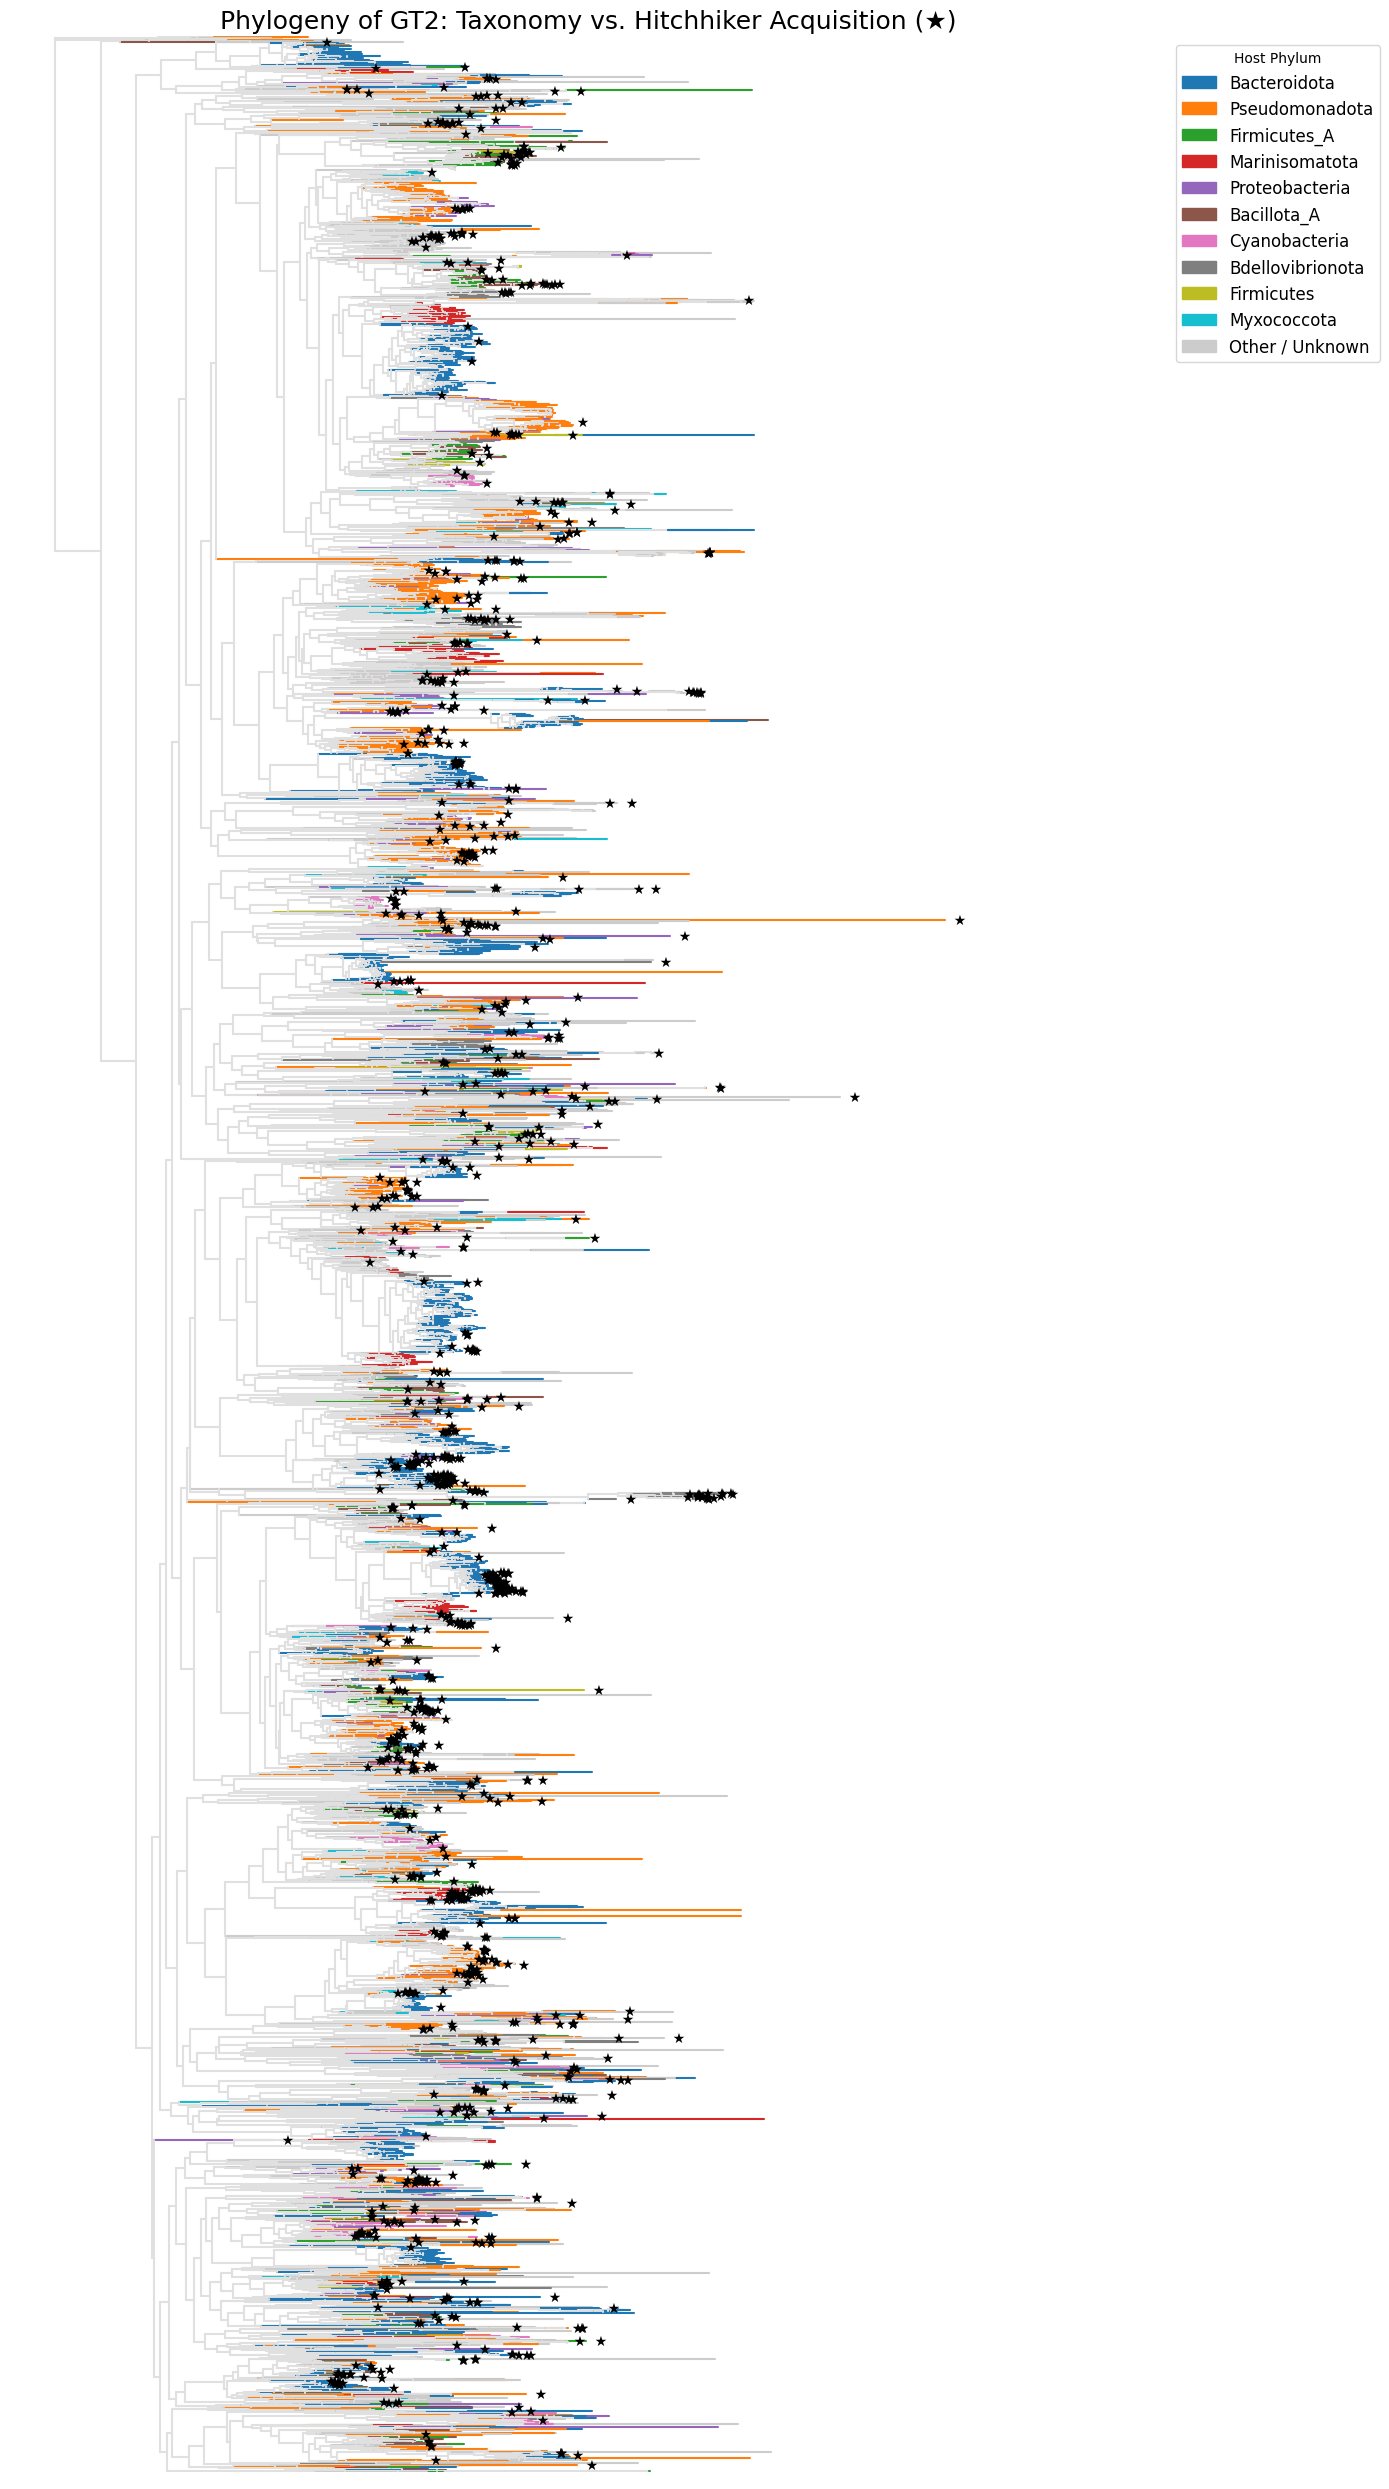

In [37]:
# =============================================================================
# Cell: Visualize Annotated Tree in Python (Taxonomy & Hitchhikers)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from Bio import Phylo
from pyspark.sql import functions as F
import os

tree_path = "data/phylogeny/GT2_gene_tree.nwk"

if not os.path.exists(tree_path):
    print(f"Error: {tree_path} not found. Please wait for FastTree to finish.")
else:
    print("Loading tree and fetching taxonomy data...")

    # 1. Load the Tree
    tree = Phylo.read(tree_path, "newick")

    # 2. Extract Genome IDs from the tree leaves
    leaf_names = [leaf.name for leaf in tree.get_terminals()]
    target_genome_ids = list(set([
        name.replace("SYNTENIC_", "").replace("CHROMOSOMAL_", "").split('_')[0] 
        for name in leaf_names if name
    ]))

    # 3. Fetch Taxonomy from Spark Database
    genome_tax = spark.table("kescience_mgnify.genome") \
        .filter(F.col("genome_id").isin(target_genome_ids)) \
        .withColumn("Phylum", F.regexp_extract(F.col("lineage"), r"p__([^;]+)", 1)) \
        .select("genome_id", "Phylum").toPandas()

    tax_dict = dict(zip(genome_tax['genome_id'], genome_tax['Phylum']))

    # 4. Generate a Color Palette for the Top 10 Phyla
    top_phyla = genome_tax['Phylum'].value_counts().nlargest(10).index.tolist()
    palette = sns.color_palette("tab10", len(top_phyla)).as_hex()
    color_map = dict(zip(top_phyla, palette))

    # 5. Apply Colors to the Tree Branches
    for clade in tree.find_clades():
        if clade.name:  # This is a terminal leaf (a gene)
            # Extract the raw genome ID
            genome_id = clade.name.replace("SYNTENIC_", "").replace("CHROMOSOMAL_", "").split('_')[0]
            phylum = tax_dict.get(genome_id, "Unknown")
            
            # Color the branch based on its Phylum (Default to light gray for rare phyla)
            clade.color = color_map.get(phylum, "#CCCCCC") 
        else:
            # Internal branches get a faint gray so the colorful tips pop out
            clade.color = "#E0E0E0"

    # 6. Define the "Hitchhiker" Labeling Function
    # We hide the messy gene IDs, but append a Star to the syntenic hitchhikers
    def highlight_hitchhikers(clade):
        if clade.name and "SYNTENIC" in clade.name:
            return " ★" 
        return ""

    # 7. Draw the Plot
    print("Rendering plot (this might take a few seconds for large trees)...")
    fig, ax = plt.subplots(figsize=(14, 25)) # Tall figure to accommodate thousands of leaves

    Phylo.draw(
        tree, 
        axes=ax, 
        do_show=False, 
        label_func=highlight_hitchhikers, 
        show_confidence=False,
        branch_labels=None
    )

    # 8. Create a Custom Legend
    legend_patches = [mpatches.Patch(color=color, label=phylum) for phylum, color in color_map.items()]
    legend_patches.append(mpatches.Patch(color="#CCCCCC", label="Other / Unknown"))
    ax.legend(handles=legend_patches, title="Host Phylum", loc="upper left", bbox_to_anchor=(1, 1), fontsize=12)

    plt.title("Phylogeny of GT2: Taxonomy vs. Hitchhiker Acquisition (★)", fontsize=18)
    plt.axis("off") # Turn off the numeric coordinate axes
    plt.tight_layout()
    plt.show()

Success! Metabolic Heatmap securely saved to 'data/Figure2_Metabolic_Heatmap.pdf'


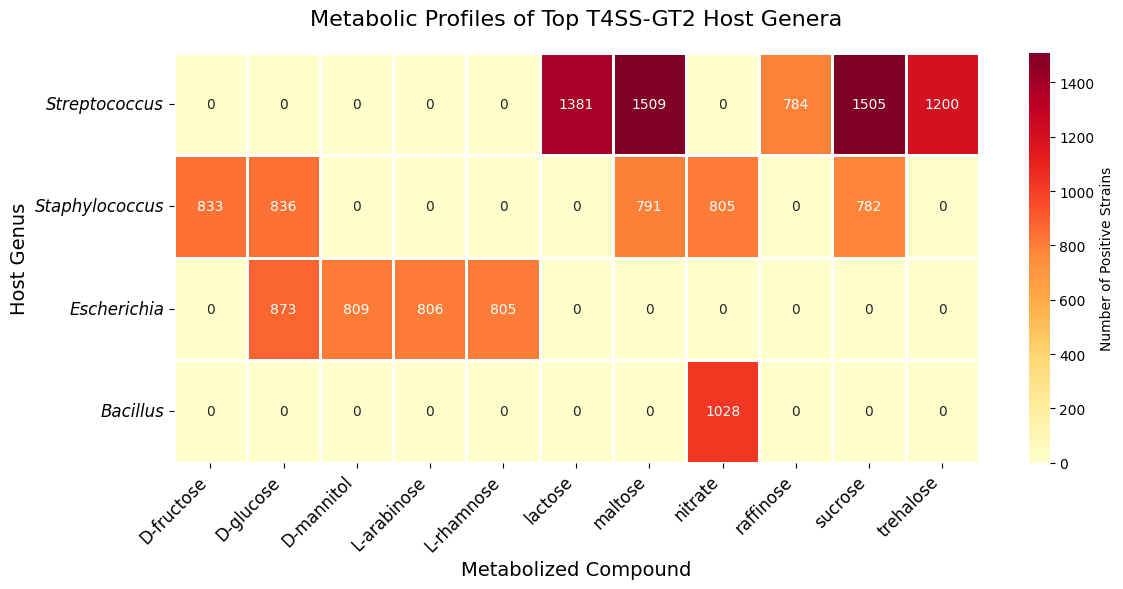

In [38]:
# =============================================================================
# Cell: Generate Figure 2 (Metabolic Diet Heatmap)
# =============================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstructing your data so this cell is self-contained
data = {
    'bacdive_genus': [
        'Streptococcus', 'Streptococcus', 'Streptococcus', 'Streptococcus', 
        'Bacillus', 'Escherichia', 'Staphylococcus', 'Staphylococcus', 
        'Escherichia', 'Escherichia', 'Escherichia', 'Staphylococcus', 
        'Staphylococcus', 'Streptococcus', 'Staphylococcus'
    ],
    'compound_name': [
        'maltose', 'sucrose', 'lactose', 'trehalose', 
        'nitrate', 'D-glucose', 'D-glucose', 'D-fructose', 
        'D-mannitol', 'L-arabinose', 'L-rhamnose', 'nitrate', 
        'maltose', 'raffinose', 'sucrose'
    ],
    'positive_strains': [
        1509, 1505, 1381, 1200, 1028, 873, 836, 833, 
        809, 806, 805, 805, 791, 784, 782
    ]
}

df = pd.DataFrame(data)

# Pivot the data so Genera are rows and Compounds are columns
pivot_df = df.pivot(index='bacdive_genus', columns='compound_name', values='positive_strains').fillna(0)

# Sort by the most metabolically active genera
pivot_df = pivot_df.loc[pivot_df.sum(axis=1).sort_values(ascending=False).index]

# Set up the plot
plt.figure(figsize=(12, 6))

# Draw the heatmap
sns.heatmap(
    pivot_df, 
    annot=True,          # Show the raw numbers inside the boxes
    fmt=".0f",           # Format as whole numbers
    cmap="YlOrRd",       # Yellow to Orange to Red color scale
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Number of Positive Strains'}
)

# Clean up labels
plt.title("Metabolic Profiles of Top T4SS-GT2 Host Genera", fontsize=16, pad=20)
plt.xlabel("Metabolized Compound", fontsize=14)
plt.ylabel("Host Genus", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12, fontstyle='italic') # Genera should be italicized!

plt.tight_layout()

# Save the figure
output_heatmap = "data/Figure2_Metabolic_Heatmap.pdf"
plt.savefig(output_heatmap, format="pdf", dpi=300)
print(f"Success! Metabolic Heatmap securely saved to '{output_heatmap}'")

plt.show()

Generating corrected integrated metabolic niche visualization...


/tmp/ipykernel_727/2999728849.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Success! Final Figure 2 saved to 'data/Figure2_Metabolic_Niche_Final.pdf'


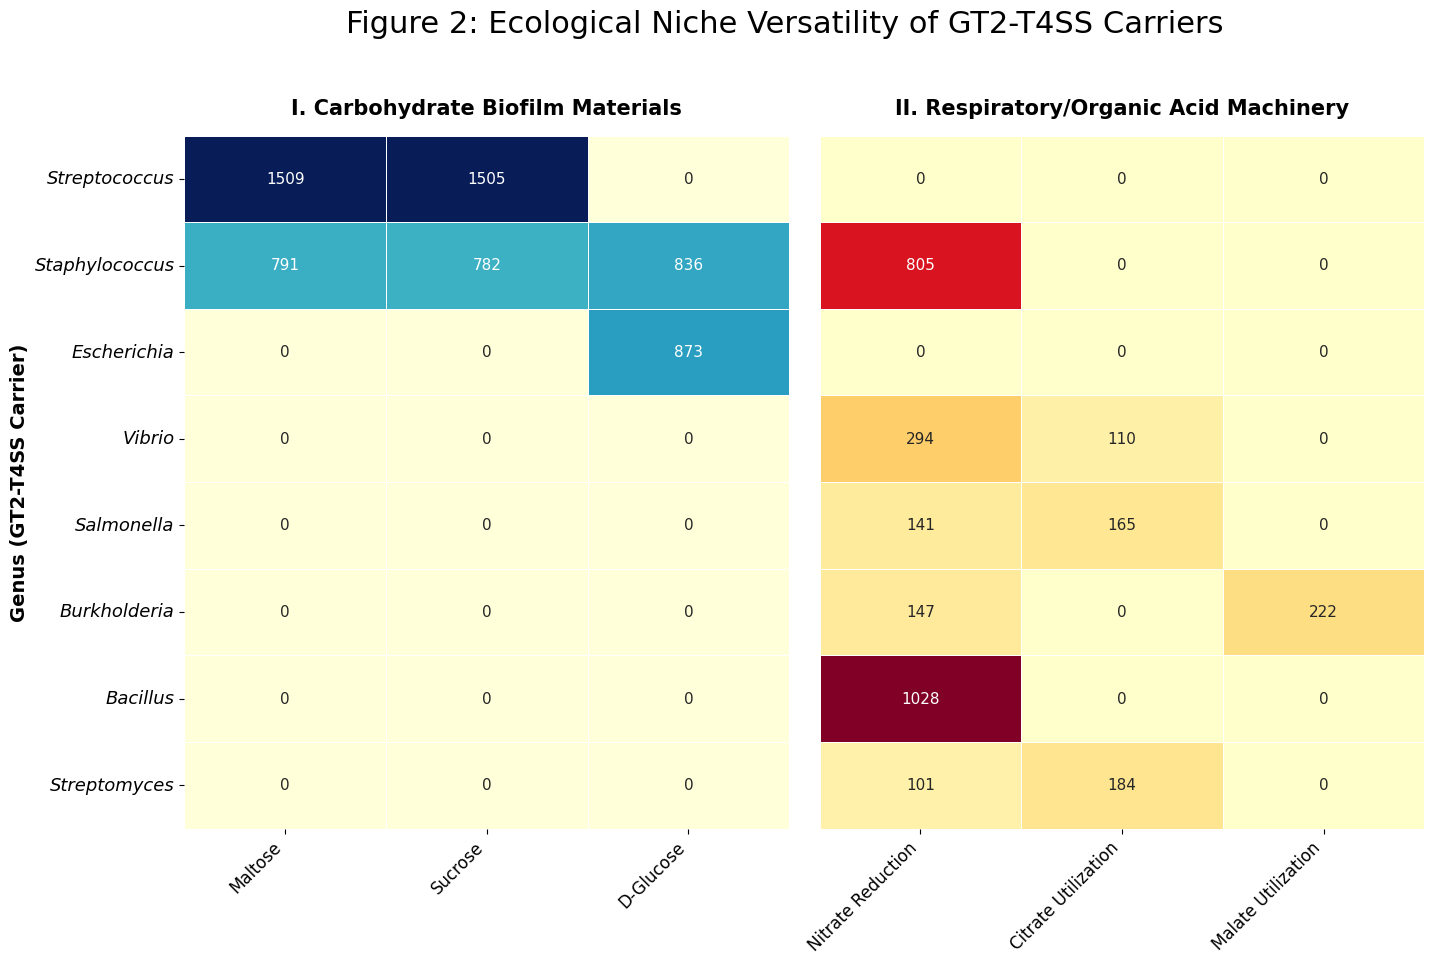

In [44]:
# =============================================================================
# Cell: Fixed Figure 2 (Integrated Metabolic Niche Heatmap)
# =============================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("Generating corrected integrated metabolic niche visualization...")

# 1. DATA CONSOLIDATION
data = {
    'Genus': [
        'Streptococcus', 'Staphylococcus', 'Escherichia', 
        'Vibrio', 'Salmonella', 'Burkholderia', 'Bacillus', 'Streptomyces'
    ],
    'Maltose': [1509, 791, 0, 0, 0, 0, 0, 0],
    'Sucrose': [1505, 782, 0, 0, 0, 0, 0, 0],
    'D-Glucose': [0, 836, 873, 0, 0, 0, 0, 0],
    'Nitrate Reduction': [0, 805, 0, 294, 141, 147, 1028, 101], 
    'Citrate Utilization': [0, 0, 0, 110, 165, 0, 0, 184],
    'Malate Utilization': [0, 0, 0, 0, 0, 222, 0, 0]
}

df_plot = pd.DataFrame(data).set_index('Genus')
carb_traits = ['Maltose', 'Sucrose', 'D-Glucose']
respiratory_traits = ['Nitrate Reduction', 'Citrate Utilization', 'Malate Utilization']
df_plot = df_plot[carb_traits + respiratory_traits]

# 2. PLOT EXECUTION
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.05)
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# Plot 1: Carbohydrate Niche (Blues/Greens)
sns.heatmap(df_plot[carb_traits], ax=ax1, annot=True, fmt="g", cmap="YlGnBu", 
            cbar=False, linewidths=.5, annot_kws={"size": 11})
ax1.set_title("I. Carbohydrate Biofilm Materials", fontsize=15, pad=15, fontweight='bold')
ax1.set_ylabel("Genus (GT2-T4SS Carrier)", fontsize=14, fontweight='bold')

# Plot 2: Respiratory/Acid Niche (Reds/Oranges)
sns.heatmap(df_plot[respiratory_traits], ax=ax2, annot=True, fmt="g", cmap="YlOrRd", 
            cbar=False, linewidths=.5, annot_kws={"size": 11})
ax2.set_title("II. Respiratory/Organic Acid Machinery", fontsize=15, pad=15, fontweight='bold')
ax2.set_ylabel("")
ax2.tick_params(axis='y', left=False, labelleft=False)

# --- THE FIX: Italicize Genus Names ---
for ax in [ax1]:
    ax.set_yticklabels(ax.get_yticklabels(), fontstyle='italic', size=13)
    ax.set_xticklabels(ax.get_xticklabels(), size=12, rotation=45, ha='right')

for ax in [ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), size=12, rotation=45, ha='right')

plt.suptitle("Figure 2: Ecological Niche Versatility of GT2-T4SS Carriers", fontsize=22, y=1.02)
plt.tight_layout()

# Save
output_heatmap = "data/Figure2_Metabolic_Niche_Final.pdf"
plt.savefig(output_heatmap, format="pdf", dpi=300, bbox_inches='tight')
print(f"Success! Final Figure 2 saved to '{output_heatmap}'")
plt.show()